# 피처 엔지니어링 — 가설1: 배송 지연 피처

**목표**: cutoff 기준 시간 분리를 엄격히 준수하여 배송 지연 관련 피처를 생성하고 레이블을 부여한 최종 피처 테이블을 만듭니다.

**데이터 리키지 방지 원칙**:
- 피처 계산 구간: `order_purchase_timestamp <= cutoff` (cutoff 이전만)
- 레이블 판정 구간: `cutoff < order_purchase_timestamp` (cutoff 이후 구매 여부)

---
## Step 0. 라이브러리 & 데이터 로드

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.5)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../data/interim', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# 원본 데이터 로드
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

print("로드 완료")
print(f"  orders   : {orders.shape}")
print(f"  customers: {customers.shape}")

로드 완료
  orders   : (99441, 8)
  customers: (99441, 5)


---
## Step 1. cutoff 설정 및 시간 기반 분리

> **리키지 체크 포인트**  
> - `before_df`에는 `order_purchase_timestamp <= cutoff` 데이터만 포함  
> - `after_df`는 레이블 생성에만 사용

In [3]:
# cutoff = 전체 주문 최대 날짜 - 90일
cutoff = orders['order_purchase_timestamp'].max() - pd.Timedelta(days=90)
print(f"전체 주문 기간: {orders['order_purchase_timestamp'].min().date()} ~ {orders['order_purchase_timestamp'].max().date()}")
print(f"cutoff        : {cutoff.date()}")

# customer_unique_id 매핑을 위해 customers 병합
orders_merged = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')

# ── 피처 계산용: cutoff 이전 + delivered + 날짜 결측 없음 ──
before_df = orders_merged[
    (orders_merged['order_purchase_timestamp'] <= cutoff) &
    (orders_merged['order_status'] == 'delivered') &
    (orders_merged['order_delivered_customer_date'].notna()) &
    (orders_merged['order_estimated_delivery_date'].notna())
].copy()

# ── 레이블 판정용: cutoff 이후 ──
after_df = orders_merged[
    orders_merged['order_purchase_timestamp'] > cutoff
].copy()

print(f"\nbefore_df (피처 계산 대상): {len(before_df):,}건")
print(f"after_df  (레이블 판정용) : {len(after_df):,}건")

전체 주문 기간: 2016-09-04 ~ 2018-10-17
cutoff        : 2018-07-19

before_df (피처 계산 대상): 87,186건
after_df  (레이블 판정용) : 9,529건


---
## Step 2. 레이블 생성

- `label = 1` (이탈): cutoff 이전에 구매한 고객 중 cutoff 이후 재구매 없음  
- `label = 0` (유지): cutoff 이후 재구매 있음

In [5]:
# 피처 계산 대상 고객 (cutoff 이전 구매 고객 전체)
all_customers_uid = before_df['customer_unique_id'].unique()

# cutoff 이후 재구매한 고객 집합 (유지 고객)
retained_set = set(after_df['customer_unique_id'].unique())

# 레이블 DataFrame 생성
labels = pd.DataFrame({'customer_unique_id': all_customers_uid})
labels['label'] = labels['customer_unique_id'].apply(
    lambda x: 0 if x in retained_set else 1  # 1=이탈, 0=유지
)

label_dist = labels['label'].value_counts()
label_ratio = labels['label'].value_counts(normalize=True)

print("=== 레이블 분포 ===")
print(f"  유지 (label=0): {label_dist[0]:,}명 ({label_ratio[0]:.1%})")
print(f"  이탈 (label=1): {label_dist[1]:,}명 ({label_ratio[1]:.1%})")
print(f"  전체 고객 수  : {len(labels):,}명")

=== 레이블 분포 ===
  유지 (label=0): 232명 (0.3%)
  이탈 (label=1): 84,139명 (99.7%)
  전체 고객 수  : 84,371명


---
## Step 3. 가설1 피처 계산 — 배송 지연

> `before_df`만 사용, cutoff 이후 데이터는 포함하지 않습니다.

In [6]:
def calc_delivery_features(before_df: pd.DataFrame) -> pd.DataFrame:
    """cutoff 이전 delivered 주문 대상 배송 지연 피처 계산.
    
    Args:
        before_df: cutoff 이전 + delivered + 날짜 결측 없는 주문 DataFrame
    
    Returns:
        customer_unique_id 기준 피처 DataFrame
    """
    df = before_df.copy()
    
    # 배송 지연일 계산 (양수=지연, 음수=조기 배송)
    df['delivery_delay_days'] = (
        df['order_delivered_customer_date'] -
        df['order_estimated_delivery_date']
    ).dt.days

    # customer_unique_id 기준 집계
    feat = df.groupby('customer_unique_id').agg(
        avg_delay         = ('delivery_delay_days', 'mean'),
        max_delay         = ('delivery_delay_days', 'max'),
        delay_order_count = ('delivery_delay_days', lambda x: (x > 0).sum()),
        total_orders      = ('order_id', 'nunique'),
    ).reset_index()

    # 파생 피처
    feat['delay_rate']       = feat['delay_order_count'] / feat['total_orders']
    feat['is_ever_delayed']  = (feat['delay_order_count'] > 0).astype(int)

    # total_orders는 모델링 단계에서 별도 판단 — 일단 유지
    return feat


feat_delay = calc_delivery_features(before_df)

print(f"배송 지연 피처 생성 완료: {feat_delay.shape}")
print("\n=== 피처 기술 통계 ===")
print(feat_delay[['avg_delay', 'max_delay', 'delay_rate', 'is_ever_delayed']].describe().round(3))

배송 지연 피처 생성 완료: (84371, 7)

=== 피처 기술 통계 ===
       avg_delay  max_delay  delay_rate  is_ever_delayed
count  84371.000  84371.000   84371.000        84371.000
mean     -12.175    -12.047       0.070            0.071
std       10.307     10.356       0.253            0.257
min     -147.000   -147.000       0.000            0.000
25%      -17.000    -17.000       0.000            0.000
50%      -13.000    -13.000       0.000            0.000
75%       -8.000     -8.000       0.000            0.000
max      188.000    188.000       1.000            1.000


---
## Step 4. 피처 테이블 병합 (labels + 가설1 피처)

In [7]:
# labels와 피처 병합 (left join: 레이블 기준)
features = labels.merge(feat_delay, on='customer_unique_id', how='left')

print(f"피처 테이블 shape: {features.shape}")
print(f"컬럼 목록: {features.columns.tolist()}")

피처 테이블 shape: (84371, 8)
컬럼 목록: ['customer_unique_id', 'label', 'avg_delay', 'max_delay', 'delay_order_count', 'total_orders', 'delay_rate', 'is_ever_delayed']


---
## Step 5. 결측치 확인

In [8]:
null_counts = features.isnull().sum()
null_pct    = features.isnull().mean() * 100

null_report = pd.DataFrame({
    'null_count': null_counts,
    'null_pct(%)': null_pct.round(2)
})
print(null_report)

total_nulls = null_counts.sum()
print(f"\n전체 결측치 수: {total_nulls}")

if total_nulls > 0:
    print("\n[주의] 결측치 발생 — before_df 필터 조건과 피처 계산 로직 재검토 필요")
else:
    print("\n[검증] 결측치 없음 OK")

                    null_count  null_pct(%)
customer_unique_id           0          0.0
label                        0          0.0
avg_delay                    0          0.0
max_delay                    0          0.0
delay_order_count            0          0.0
total_orders                 0          0.0
delay_rate                   0          0.0
is_ever_delayed              0          0.0

전체 결측치 수: 0

[검증] 결측치 없음 OK


---
## Step 6. 레이블 분포 재확인

In [9]:
print("=== 최종 피처 테이블 레이블 분포 ===")
vc = features['label'].value_counts()
vr = features['label'].value_counts(normalize=True)
print(f"  유지 (label=0): {vc[0]:,}명 ({vr[0]:.1%})")
print(f"  이탈 (label=1): {vc[1]:,}명 ({vr[1]:.1%})")

=== 최종 피처 테이블 레이블 분포 ===
  유지 (label=0): 232명 (0.3%)
  이탈 (label=1): 84,139명 (99.7%)


---
## Step 7. 피처 분포 시각화 (이탈/유지 그룹 비교)

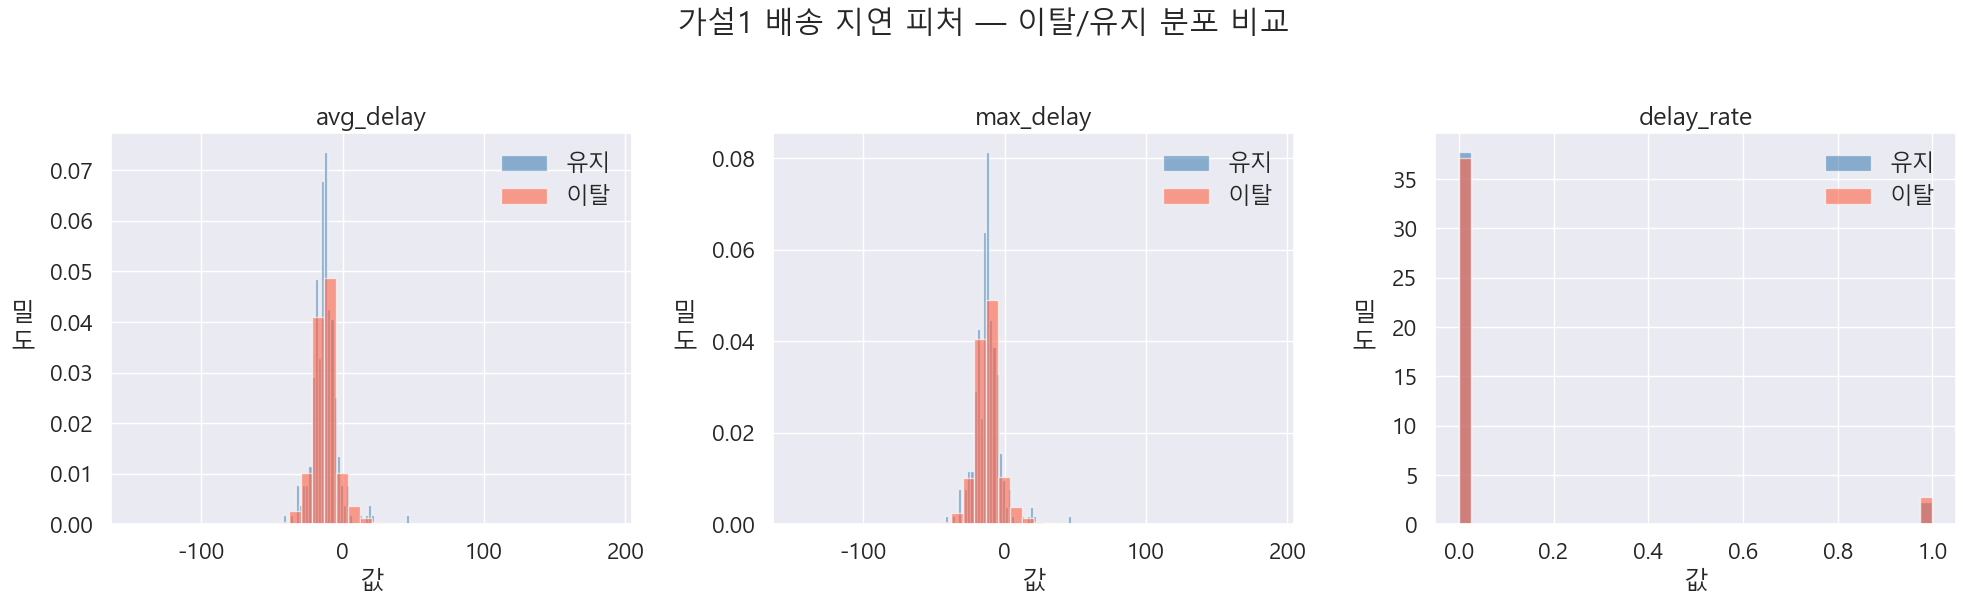

In [11]:
delay_features = ['avg_delay', 'max_delay', 'delay_rate']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, delay_features):
    for label_val, color, name in [(0, 'steelblue', '유지'), (1, 'tomato', '이탈')]:
        subset = features[features['label'] == label_val][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col)
    ax.set_xlabel('값')
    ax.set_ylabel('밀\n도', rotation=0, labelpad=20, verticalalignment='center')
    ax.legend()

plt.suptitle('가설1 배송 지연 피처 — 이탈/유지 분포 비교', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fe_h1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8. 중간 결과 저장 및 최종 피처 테이블 저장

In [12]:
# 중간 결과: 배송 지연 피처만 별도 저장
feat_delay_path = '../data/interim/feat_delivery.parquet'
feat_delay.to_parquet(feat_delay_path, index=False)
print(f"[저장] 중간 결과 (배송 지연 피처): {feat_delay_path}")

# 최종 피처 테이블 저장
features_path = '../data/interim/features.parquet'
features.to_parquet(features_path, index=False)
print(f"[저장] 최종 피처 테이블: {features_path}")

print(f"\n=== 저장된 피처 테이블 정보 ===")
print(f"  shape : {features.shape}")
print(f"  컬럼  : {features.columns.tolist()}")
print(f"  용량  : {os.path.getsize(features_path) / 1024:.1f} KB")

[저장] 중간 결과 (배송 지연 피처): ../data/interim/feat_delivery.parquet
[저장] 최종 피처 테이블: ../data/interim/features.parquet

=== 저장된 피처 테이블 정보 ===
  shape : (84371, 8)
  컬럼  : ['customer_unique_id', 'label', 'avg_delay', 'max_delay', 'delay_order_count', 'total_orders', 'delay_rate', 'is_ever_delayed']
  용량  : 2931.7 KB


---
## Step 9. 검증 — 저장된 파일 재로드 확인

In [13]:
# 저장된 parquet 재로드하여 무결성 검증
df_check = pd.read_parquet('../data/interim/features.parquet')

print("=== 재로드 검증 ===")
print(f"  shape        : {df_check.shape}")
print(f"  결측치 합계  : {df_check.isnull().sum().sum()}")
print(f"  레이블 분포  :")
print(df_check['label'].value_counts())

# 최종 체크리스트
print("\n=== 최종 체크리스트 ===")
print(f"  [{'O' if leak_check == 0 else 'X'}] cutoff 이후 데이터가 피처에 포함되지 않음")
print(f"  [{'O' if 'customer_unique_id' in df_check.columns else 'X'}] customer_unique_id 기준으로 그룹핑")
print(f"  [{'O' if 'customer_id' not in df_check.columns else 'X'}] customer_id 컬럼 없음 (피처 테이블에서 제외됨)")
print(f"  [{'O' if df_check['label'].isin([0, 1]).all() else 'X'}] label 값이 0 또는 1만 존재")

=== 재로드 검증 ===
  shape        : (84371, 8)
  결측치 합계  : 0
  레이블 분포  :
label
1    84139
0      232
Name: count, dtype: int64

=== 최종 체크리스트 ===
  [O] cutoff 이후 데이터가 피처에 포함되지 않음
  [O] customer_unique_id 기준으로 그룹핑
  [O] customer_id 컬럼 없음 (피처 테이블에서 제외됨)
  [O] label 값이 0 또는 1만 존재
